In [1]:
import os
from glob import glob
from monai.transforms import (
    LoadImaged, 
    Compose, 
    ResizeWithPadOrCropd, 
    EnsureChannelFirstd, 
    CropForegroundd, 
    RandCropByPosNegLabeld, 
    Orientationd, 
    Spacingd, 
    ScaleIntensityRanged,
    SpatialPadd,
    ScaleIntensityRangePercentilesd,
)
import matplotlib.pyplot as plt
import torch
import numpy as np


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\Sawitt\AppData\Local\Programs\Python\Python312\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\Sawitt\AppData\Local\Programs\Python\Python312\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\Users\Sawitt\AppData\Local\Programs\Python\Python312\Lib\site-packages\ipykernel\kernelapp.py

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



In [3]:
image_dir = "dummy/images"
segment_dir = "dummy/masks"

images = sorted(glob(os.path.join(image_dir, "*.nii.gz")))
segments = sorted(glob(os.path.join(segment_dir, "*.nii.gz")))

pairs = list(zip(images, segments))
print(pairs)

[('dummy/images\\1.3.6.1.4.1.9328.50.4.0001.nii.gz', 'dummy/masks\\1.3.6.1.4.1.9328.50.4.0001.nii.gz'), ('dummy/images\\1.3.6.1.4.1.9328.50.4.0002.nii.gz', 'dummy/masks\\1.3.6.1.4.1.9328.50.4.0002.nii.gz'), ('dummy/images\\1.3.6.1.4.1.9328.50.4.0003.nii.gz', 'dummy/masks\\1.3.6.1.4.1.9328.50.4.0003.nii.gz'), ('dummy/images\\1.3.6.1.4.1.9328.50.4.0004.nii.gz', 'dummy/masks\\1.3.6.1.4.1.9328.50.4.0004.nii.gz'), ('dummy/images\\1.3.6.1.4.1.9328.50.4.0005.nii.gz', 'dummy/masks\\1.3.6.1.4.1.9328.50.4.0005.nii.gz')]


Unique values in mask: [ 0. 14. 15. 16. 17. 18. 19. 20. 21. 22. 23. 24.]
Image shape: torch.Size([512, 512, 604]), Mask shape: torch.Size([512, 512, 604])
Spacing: [1.      0.78125 0.78125 0.8     0.      0.      0.      0.     ]


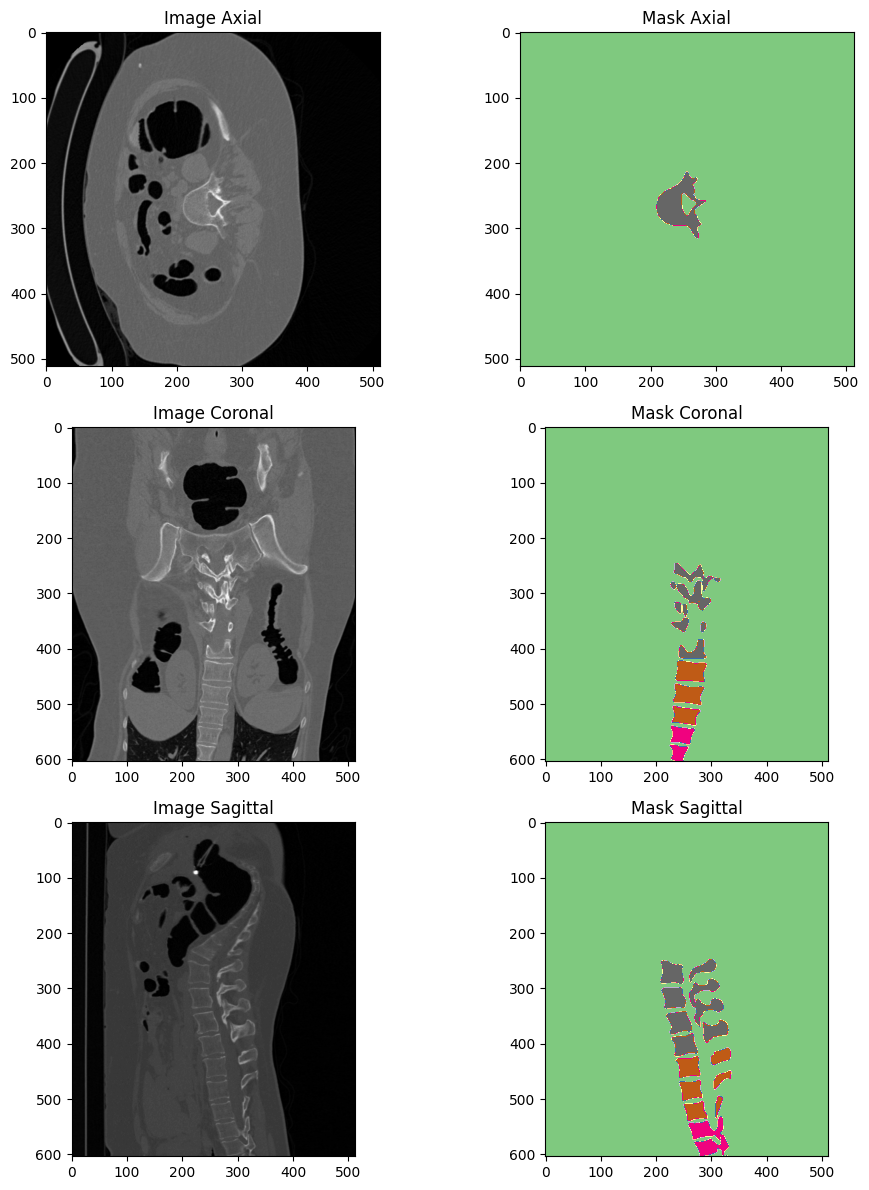

Unique values in mask: [ 0. 13. 14. 15. 16. 17. 18. 19. 20. 21. 22. 23. 24.]
Image shape: torch.Size([512, 512, 637]), Mask shape: torch.Size([512, 512, 637])
Spacing: [1.      0.78125 0.78125 0.8     0.      0.      0.      0.     ]


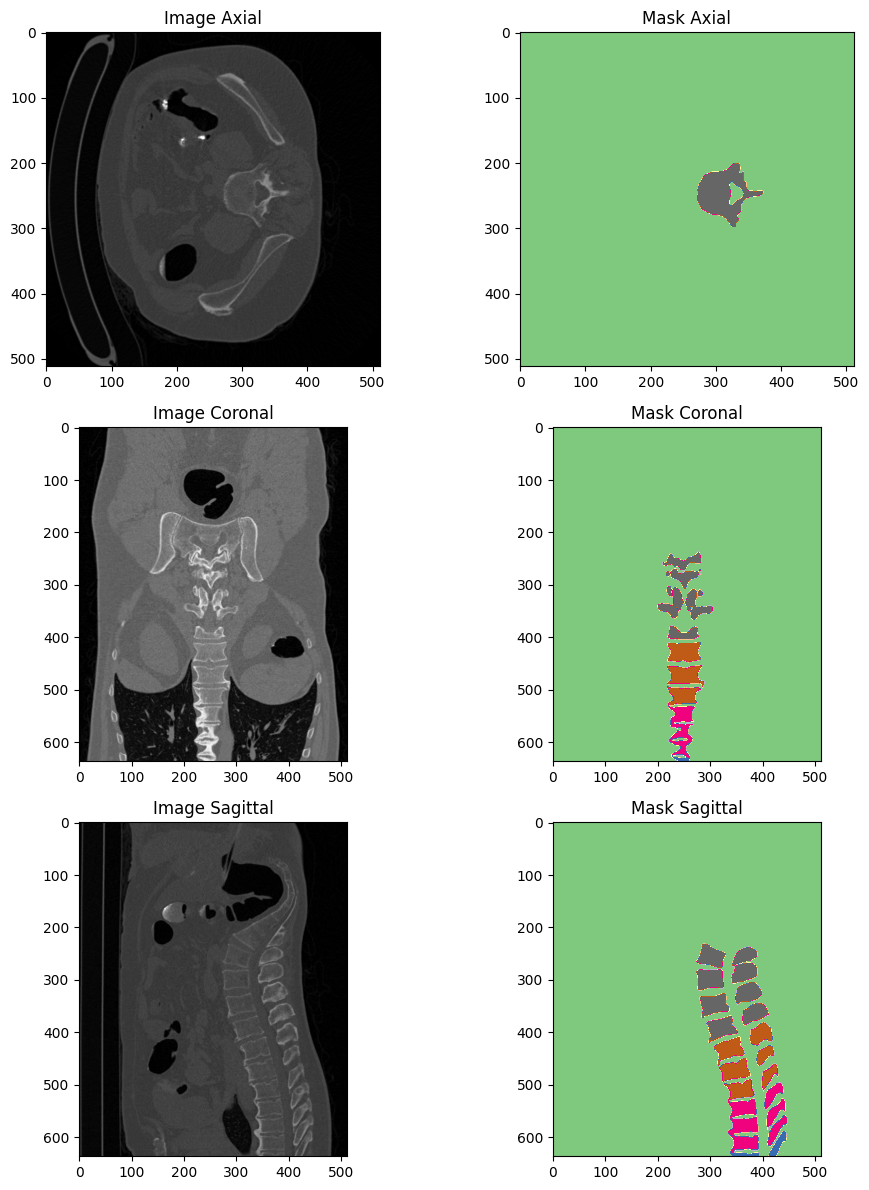

Unique values in mask: [ 0. 11. 12. 13. 14. 15. 16. 17. 18. 19. 20. 21. 22. 23. 24.]
Image shape: torch.Size([512, 512, 663]), Mask shape: torch.Size([512, 512, 663])
Spacing: [1.      0.78125 0.78125 0.8     0.      0.      0.      0.     ]


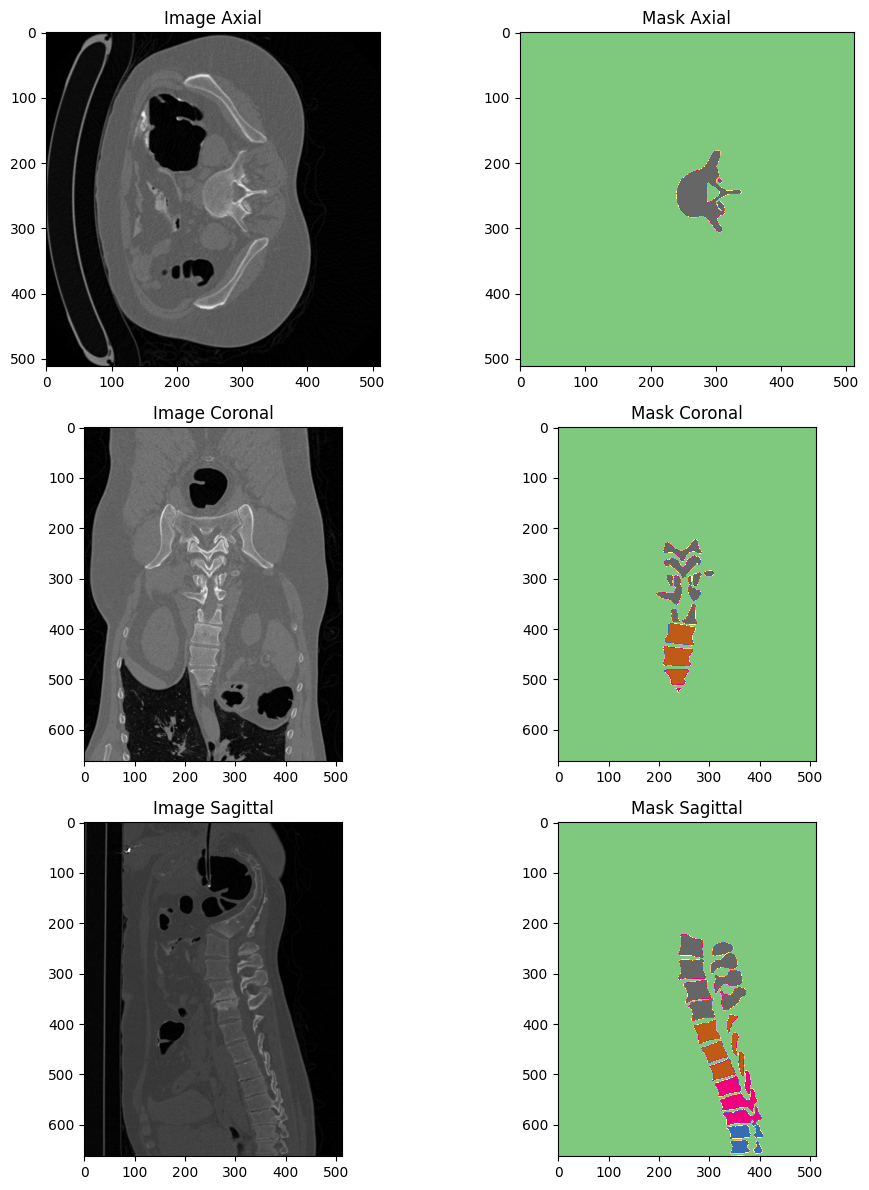

Unique values in mask: [ 0. 16. 17. 18. 19. 20. 21. 22. 23. 24. 25.]
Image shape: torch.Size([512, 512, 520]), Mask shape: torch.Size([512, 512, 520])
Spacing: [1.      0.78125 0.78125 0.8     0.      0.      0.      0.     ]


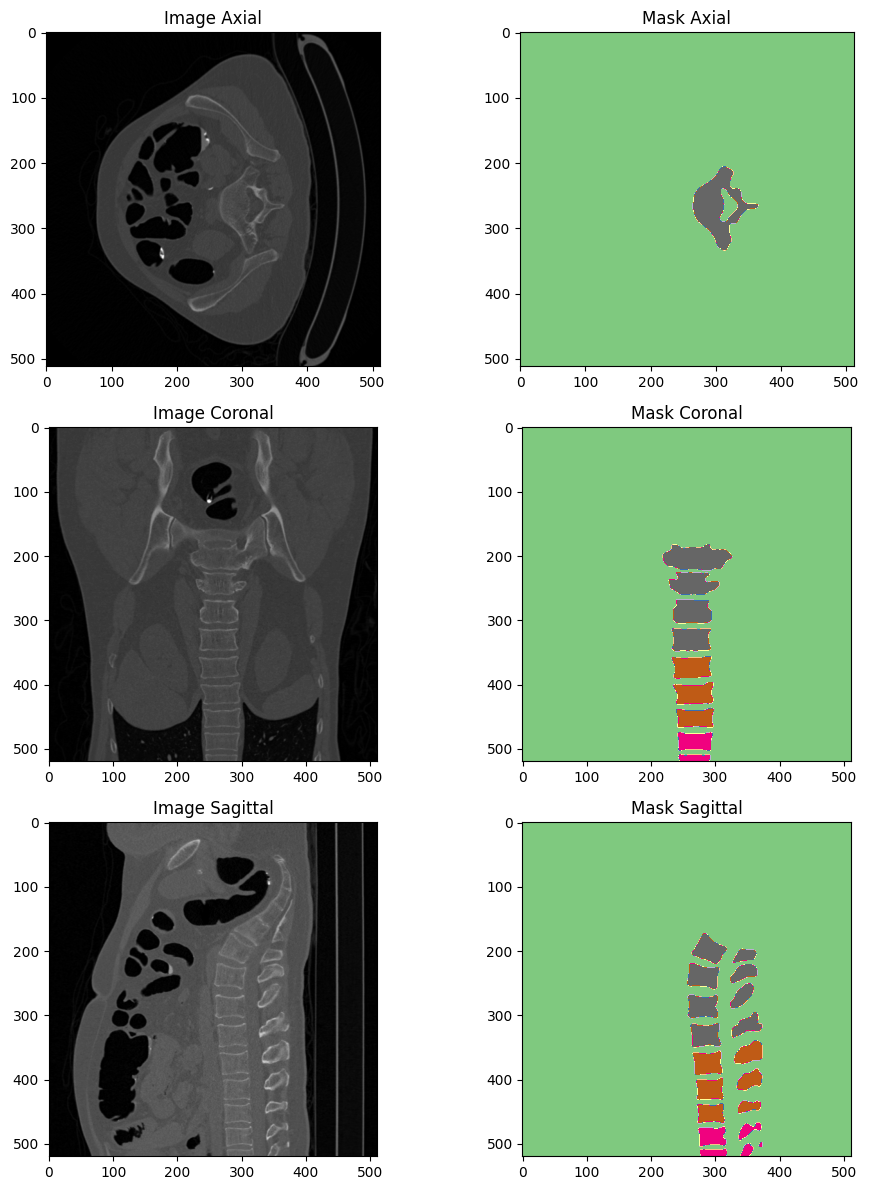

Unique values in mask: [ 0. 16. 17. 18. 19. 20. 21. 22. 23. 24.]
Image shape: torch.Size([512, 512, 401]), Mask shape: torch.Size([512, 512, 401])
Spacing: [1.         0.60546875 0.60546875 1.         0.         0.
 0.         0.        ]


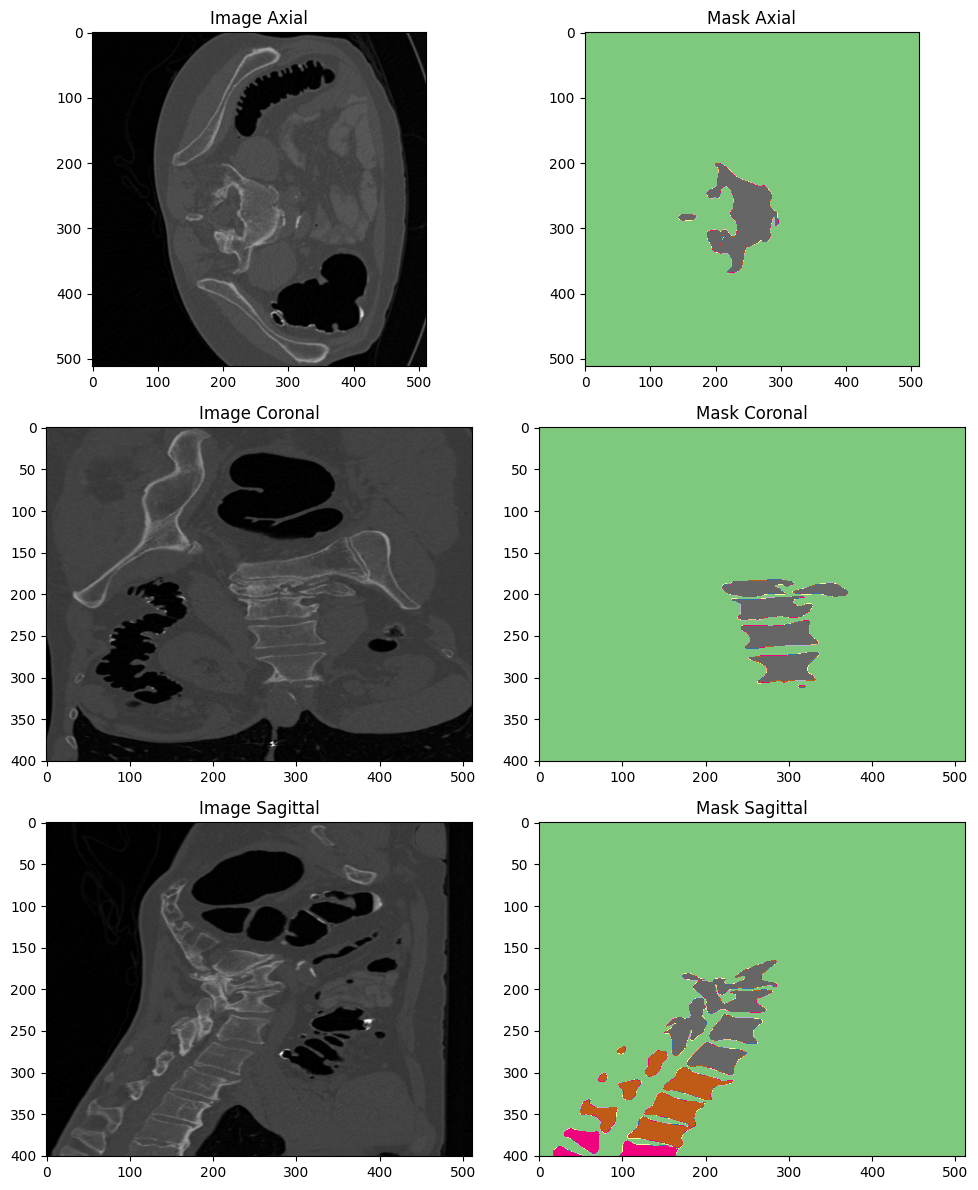

In [7]:
loader = LoadImaged(keys = ["image", "mask"], image_only = False)
for image_path, mask_path in pairs:
    data = loader({"image": image_path, "mask": mask_path})
    image = data["image"]
    mask = data["mask"]

    print("Unique values in mask:", np.unique(mask))
    print(f"Image shape: {image.shape}, Mask shape: {mask.shape}")
    print(f"Spacing: {image.meta["pixdim"]}")

    fig, ax = plt.subplots(3, 2, figsize=(10, 12))

    axial = torch.argmax(mask.sum(dim=(0,1)))
    coronal = torch.argmax(mask.sum(dim=(0,2)))
    sagittal = torch.argmax(mask.sum(dim=(1,2)))
    
    # Axial
    ax[0,0].imshow(image[:,:,axial], cmap="gray")
    ax[0,0].set_title("Image Axial")

    ax[0,1].imshow(mask[:,:,axial], cmap="Accent")
    ax[0,1].set_title("Mask Axial")

    # Coronal
    ax[1,0].imshow(image[:,coronal,:].T, cmap="gray")
    ax[1,0].set_title("Image Coronal")

    ax[1,1].imshow(mask[:,coronal,:].T, cmap="Accent")
    ax[1,1].set_title("Mask Coronal")

    # Sagittal
    ax[2,0].imshow(image[sagittal,:,:].T, cmap="gray")
    ax[2,0].set_title("Image Sagittal")

    ax[2,1].imshow(mask[sagittal,:,:].T, cmap="Accent")
    ax[2,1].set_title("Mask Sagittal")

    plt.tight_layout()
    plt.show()

c:\Users\Sawitt\AppData\Local\Programs\Python\Python312\Lib\site-packages\monai\utils\deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


Image shape: torch.Size([1, 256, 256, 256]), Mask shape: torch.Size([1, 256, 256, 256])
Spacing: tensor([[   1.0000,    0.0000,    0.0000, -137.6094],
        [   0.0000,    1.0000,    0.0000, -307.6094],
        [   0.0000,    0.0000,    1.0000, -405.9000],
        [   0.0000,    0.0000,    0.0000,    1.0000]], dtype=torch.float64)
Unique values in axial slice: [ 0. 24.]
Unique values in coronal slice: [ 0. 19. 20. 21. 22. 23. 24.]
Unique values in sagittal slice: [ 0. 18. 19. 20. 21. 22. 23. 24.]


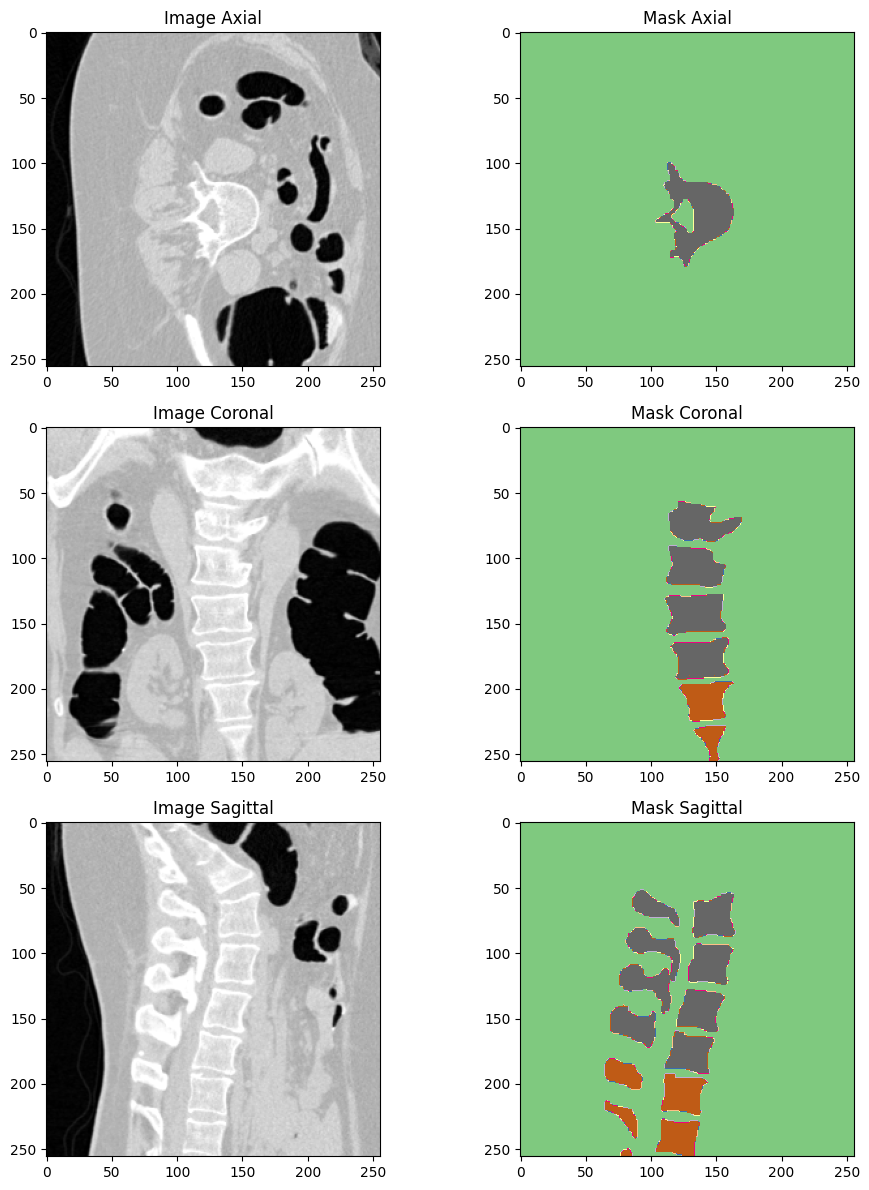

Image shape: torch.Size([1, 256, 256, 256]), Mask shape: torch.Size([1, 256, 256, 256])
Spacing: tensor([[   1.0000,    0.0000,    0.0000, -120.6094],
        [   0.0000,    1.0000,    0.0000, -363.6094],
        [   0.0000,    0.0000,    1.0000, -335.3000],
        [   0.0000,    0.0000,    0.0000,    1.0000]], dtype=torch.float64)
Unique values in axial slice: [ 0. 23. 24.]
Unique values in coronal slice: [ 0. 16. 17. 18. 19. 20. 21. 22. 23. 24.]
Unique values in sagittal slice: [ 0. 15. 16. 17. 18. 19. 20. 21. 22. 23. 24.]


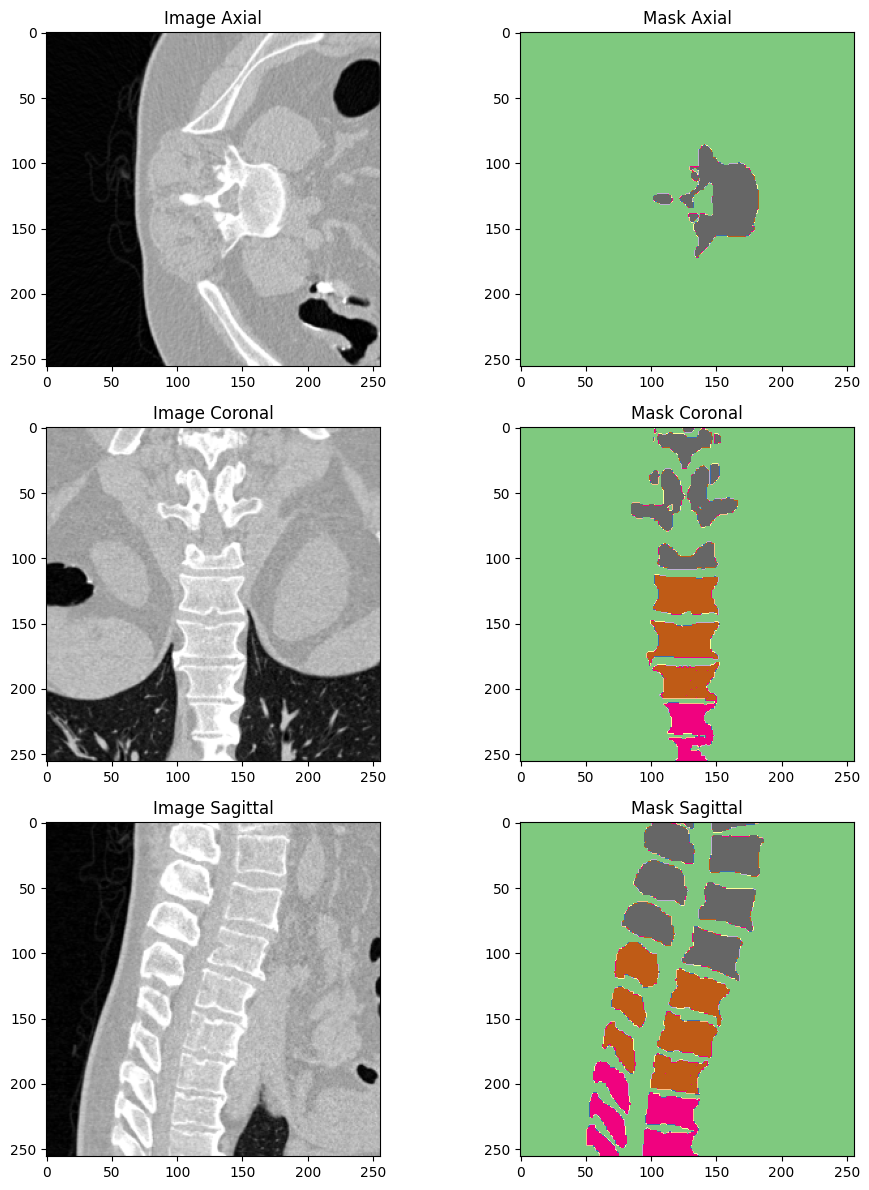

Image shape: torch.Size([1, 256, 256, 256]), Mask shape: torch.Size([1, 256, 256, 256])
Spacing: tensor([[   1.0000,    0.0000,    0.0000, -138.6094],
        [   0.0000,    1.0000,    0.0000,  111.3906],
        [   0.0000,    0.0000,    1.0000, -480.6000],
        [   0.0000,    0.0000,    0.0000,    1.0000]], dtype=torch.float64)
Unique values in axial slice: [ 0. 23. 24.]
Unique values in coronal slice: [ 0. 20. 21. 22. 23. 24.]
Unique values in sagittal slice: [ 0. 19. 20. 21. 22. 23. 24.]


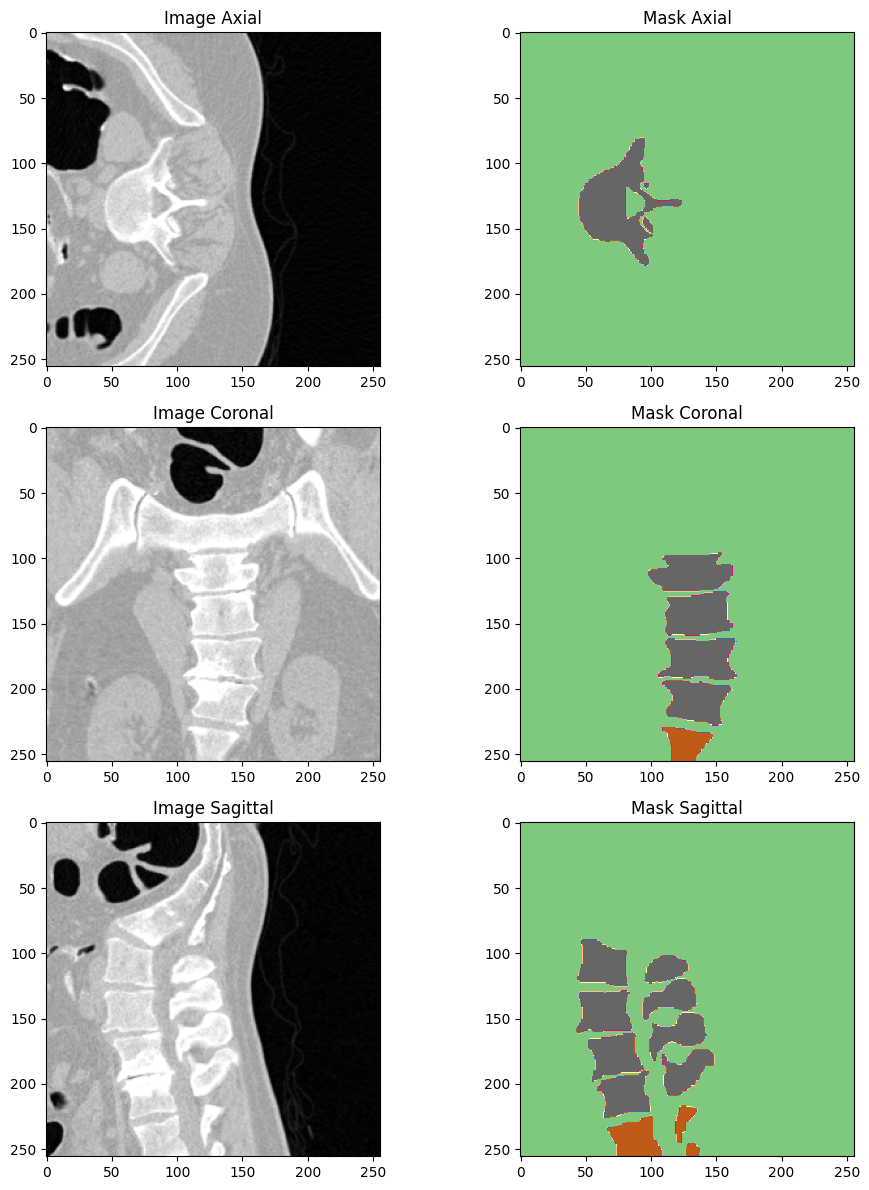

Image shape: torch.Size([1, 256, 256, 256]), Mask shape: torch.Size([1, 256, 256, 256])
Spacing: tensor([[   1.0000,    0.0000,    0.0000, -149.6094],
        [   0.0000,    1.0000,    0.0000,  -34.6094],
        [   0.0000,    0.0000,    1.0000, -345.2000],
        [   0.0000,    0.0000,    0.0000,    1.0000]], dtype=torch.float64)
Unique values in axial slice: [ 0. 25.]
Unique values in coronal slice: [ 0. 17. 18. 19. 20. 21. 22. 23. 24. 25.]
Unique values in sagittal slice: [ 0. 17. 18. 19. 20. 21. 22. 23. 24. 25.]


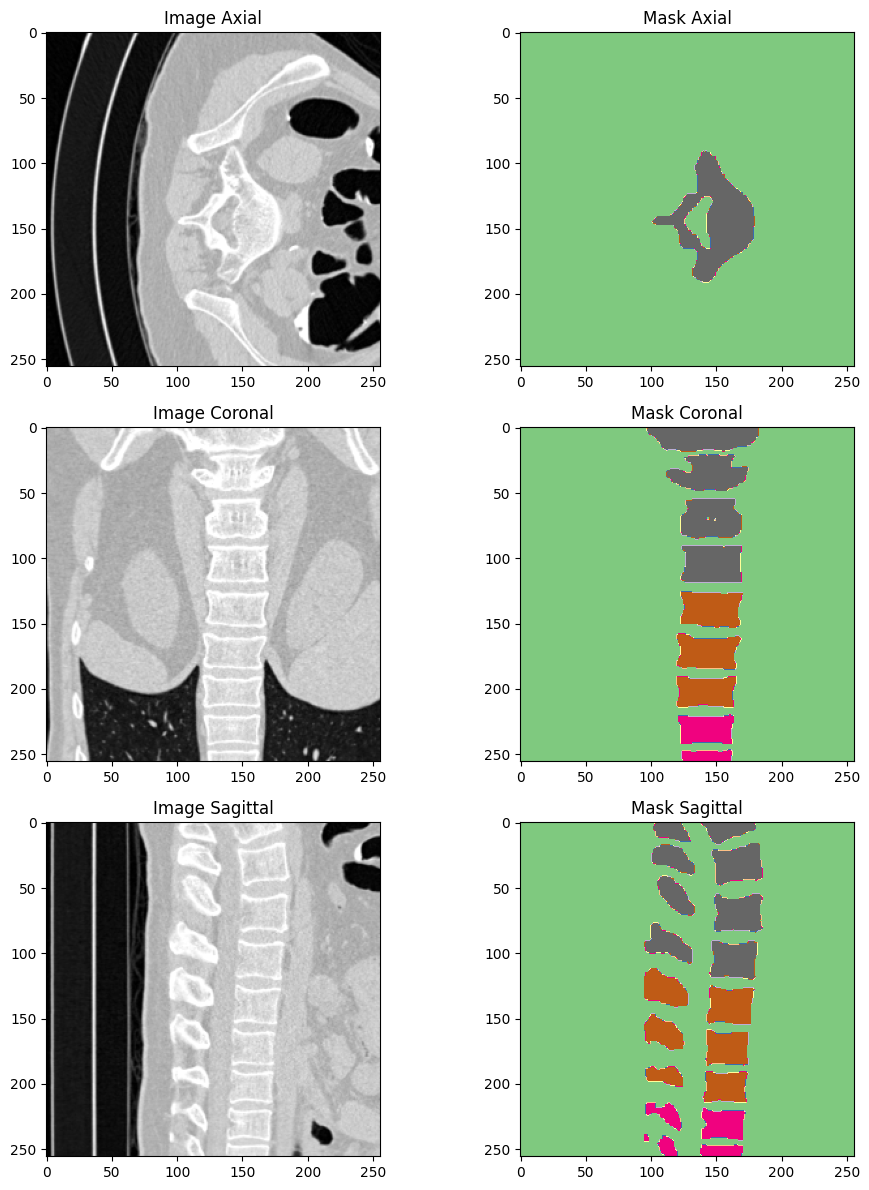

Image shape: torch.Size([1, 256, 256, 256]), Mask shape: torch.Size([1, 256, 256, 256])
Spacing: tensor([[   1.0000,    0.0000,    0.0000, -154.6973],
        [   0.0000,    1.0000,    0.0000, -278.6973],
        [   0.0000,    0.0000,    1.0000, -726.0000],
        [   0.0000,    0.0000,    0.0000,    1.0000]], dtype=torch.float64)
Unique values in axial slice: [ 0. 23. 24.]
Unique values in coronal slice: [ 0. 21. 22. 23. 24.]
Unique values in sagittal slice: [ 0. 20. 21. 22. 23. 24.]


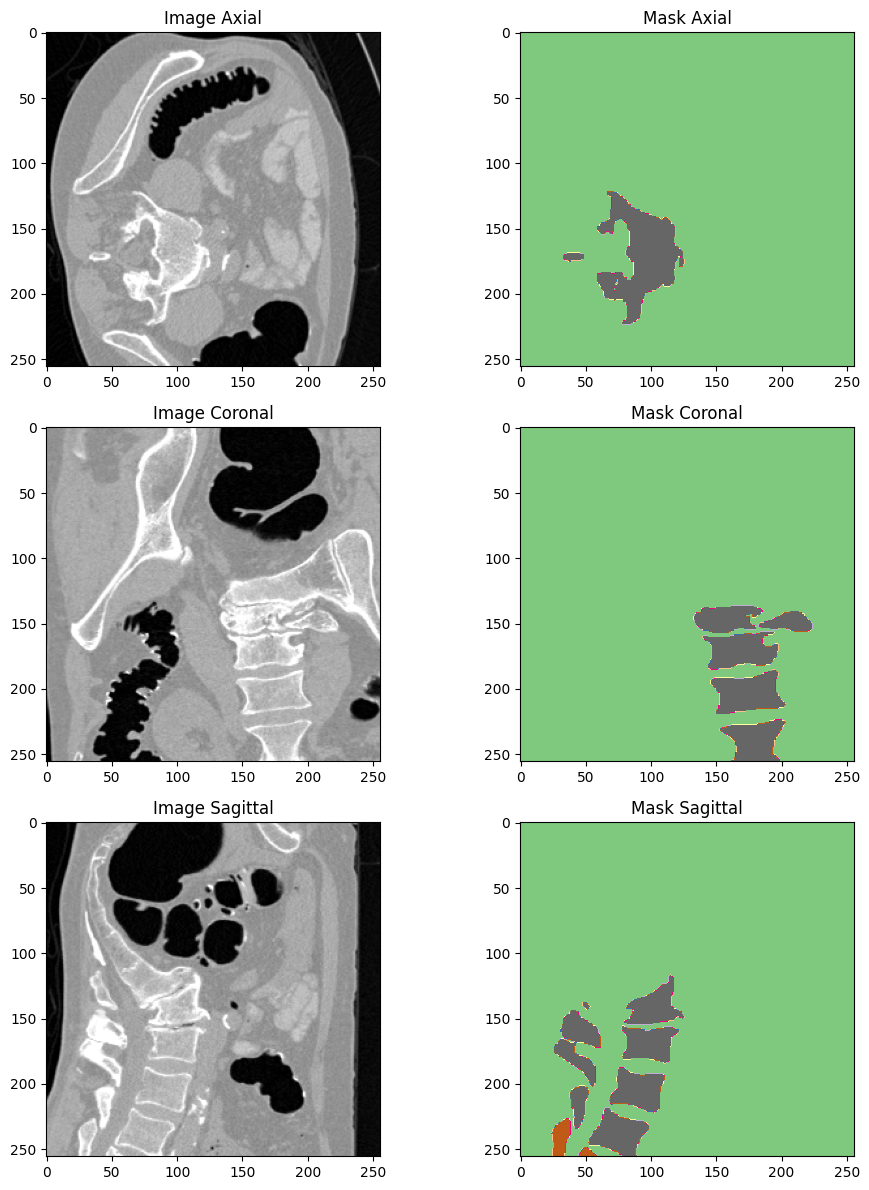

In [49]:
transforms = Compose([
    LoadImaged(keys = ["image","mask"]),

#     ScaleIntensityRanged(keys = ["image"], a_min = -1000, 
#                         a_max = 1000,
#                         b_min = 0,
#                         b_max = 1,
#                         clip = True),
    ScaleIntensityRangePercentilesd(keys = ["image"],
                                    lower = 5,
                                    upper = 99,
                                    b_min = 0,
                                    b_max = 1,
                                    clip = True
    ),
    EnsureChannelFirstd(keys = ["image", "mask"]),
    Orientationd(keys = ["image", "mask"], 
              axcodes = "RAS"),
    Spacingd(keys = ["image", "mask"],
            pixdim = (1.0, 1.0, 1.0),
            mode = ("trilinear", "nearest")),
    RandCropByPosNegLabeld(keys = ["image", "mask"], 
                           label_key = "mask", 
                           spatial_size = (256, 256, 256), 
                           pos = 3, neg = 1)    
])

for image_path, mask_path in pairs:
    data = transforms({"image": image_path, "mask": mask_path})[0]
    image = data["image"]
    mask = data["mask"]

    
    print(f"Image shape: {image.shape}, Mask shape: {mask.shape}")
    print("Spacing:", image.meta["affine"])

    fig, ax = plt.subplots(3, 2, figsize=(10, 12))

    axial = torch.argmax(mask[0].sum(dim = (0,1)))
    coronal = torch.argmax(mask[0].sum(dim = (0,2)))
    sagittal = torch.argmax(mask[0].sum(dim = (1,2)))

    # Axial
    print("Unique values in axial slice:", np.unique(mask[0,:,:,:][:,:,axial]))
    ax[0,0].imshow(image[0,:,:,:][:,:,axial], cmap="gray")
    ax[0,0].set_title("Image Axial")

    ax[0,1].imshow(mask[0,:,:,:][:,:,axial], cmap="Accent")
    ax[0,1].set_title("Mask Axial")

    # Coronal
    print("Unique values in coronal slice:", np.unique(mask[0,:,:,:][:,coronal,:]))
    ax[1,0].imshow(image[0,:,:,:][:,coronal,:].T, cmap="gray")
    ax[1,0].set_title("Image Coronal")

    ax[1,1].imshow(mask[0,:,:,:][:,coronal,:].T, cmap="Accent")
    ax[1,1].set_title("Mask Coronal")

    # Sagittal
    print("Unique values in sagittal slice:", np.unique(mask[0,:,:,:][sagittal,:,:]))
    ax[2,0].imshow(image[0,:,:,:][sagittal,:,:].T, cmap="gray")
    ax[2,0].set_title("Image Sagittal")

    ax[2,1].imshow(mask[0,:,:,:][sagittal,:,:].T, cmap="Accent")
    ax[2,1].set_title("Mask Sagittal")

    plt.tight_layout()
    plt.show()